# PLAIN IVF RESULTS

Metrics covered:
- `MRR@10` — Mean Reciprocal Rank at cutoff 10
- `NDCG@3` — Normalized Discounted Cumulative Gain at cutoff 3
- `NDCG@10` — Normalized Discounted Cumulative Gain at cutoff 10
- `avg_query_time_ms` — Average query latency in milliseconds

---
## What each metric measures

| Metric | What it rewards | Sensitive to |
|--------|----------------|---------------|
| **MRR@10** | Finding *any* relevant doc as early as possible | Position of the **first** hit |
| **NDCG@3** | High-quality top-3 ranking | Precision in the **very top** results |
| **NDCG@10** | Ranking quality across the full top-10 | **Recall** + ordering in the top-10 |

In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})



COLORS = {'MRR@10': '#4C72B0', 'NDCG@3': '#DD8452', 'NDCG@10': '#55A868'}
MARKERS = {'MRR@10': 'o', 'NDCG@3': 's', 'NDCG@10': '^'}
RED, GREEN, ACCENT = '#DD4444', '#2CA02C', '#4C72B0'

# ── Load data ─────────────────────────────────────────────────────────────────
with open('../indexes/metrics_ivf_grid.json') as f:
    raw = json.load(f)

df = pd.DataFrame(raw).T.reset_index(drop=True)
df = df.astype({'nprobe': int, 'avg_query_time_ms': float,
                'MRR@10': float, 'NDCG@3': float, 'NDCG@10': float})
df = df.sort_values('nprobe').reset_index(drop=True)

# derived columns
df['latency_gain_pct'] = df['avg_query_time_ms'].pct_change().mul(100)
df['mrr_gain']         = df['MRR@10'].diff()
df['ndcg10_gain']      = df['NDCG@10'].diff()
df['efficiency']       = df['MRR@10'] / df['avg_query_time_ms']   # quality per ms

df[['nprobe','avg_query_time_ms','MRR@10','NDCG@3','NDCG@10']].style\
  .format({'avg_query_time_ms': '{:.2f}', 'MRR@10': '{:.4f}', 'NDCG@3': '{:.4f}', 'NDCG@10': '{:.4f}'})\
  .background_gradient(subset=['MRR@10','NDCG@3','NDCG@10'], cmap='Blues')\
  .background_gradient(subset=['avg_query_time_ms'], cmap='Oranges')\
  .set_caption('nprobe sweep — all metrics')

,nprobe,avg_query_time_ms,MRR@10,NDCG@3,NDCG@10
0,1,0.81,0.6378,0.3920,0.3313
1,2,0.83,0.6747,0.4425,0.3862
2,4,0.94,0.7311,0.4829,0.4226
3,8,1.27,0.7570,0.5007,0.4407
4,16,1.84,0.7616,0.5007,0.4415
5,32,3.10,0.7805,0.5209,0.4622
6,64,5.56,0.7772,0.5315,0.4722
7,128,10.17,0.7947,0.5412,0.4838
8,256,19.37,0.7978,0.5415,0.4897
9,512,37.33,0.8007,0.5452,0.4927


## 1 · Quality metrics vs nprobe

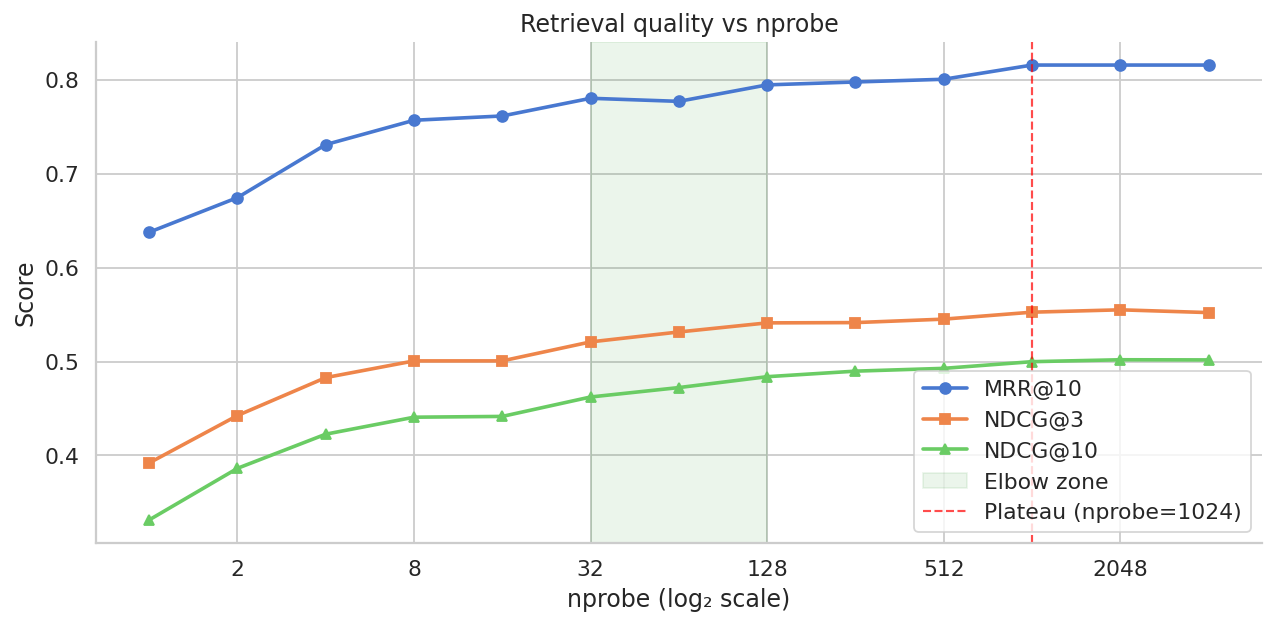

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for col, label, color, marker in [
    ('MRR@10',  'MRR@10',  '#4C72B0', 'o'),
    ('NDCG@3',  'NDCG@3',  '#DD8452', 's'),
    ('NDCG@10', 'NDCG@10', '#55A868', '^'),
]:
    ax.plot(df['nprobe'], df[col], marker=marker, label=label, linewidth=2, markersize=6)

# annotate elbow region (nprobe=32 → 128)
ax.axvspan(32, 128, alpha=0.08, color='green', label='Elbow zone')
ax.axvline(1024, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Plateau (nprobe=1024)')

ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: int(x)))
ax.set_xlabel('nprobe (log₂ scale)')
ax.set_ylabel('Score')
ax.set_title('Retrieval quality vs nprobe')
ax.legend()
plt.tight_layout()
plt.savefig('quality_vs_nprobe.png', bbox_inches='tight')
plt.show()

## 2 -Retrieval Effectiveness vs Query Time

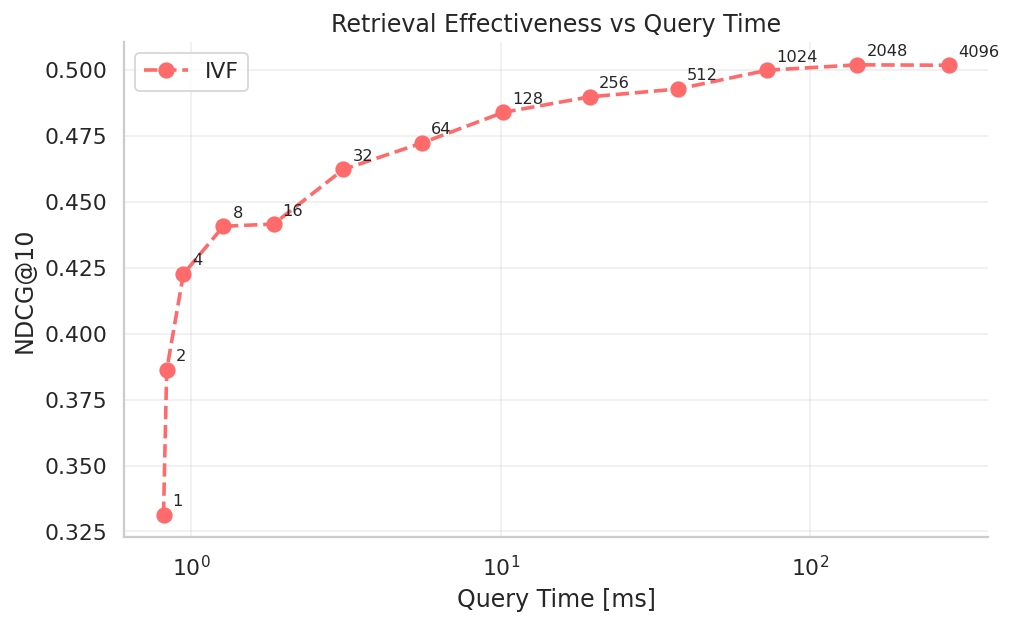

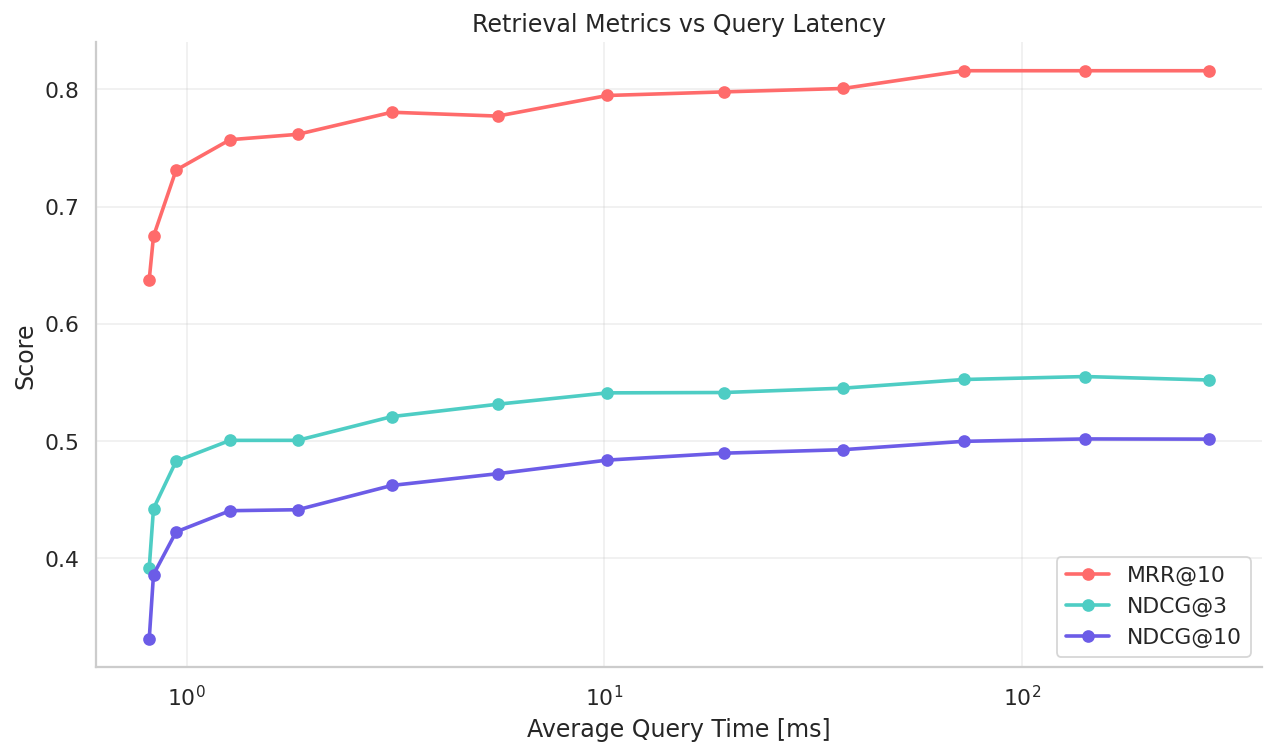

Figure saved as ivf_tradeoff.png


In [13]:
# Cell 4 -----------------------------------------------------
# Main plot (similar to your example image)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df["avg_query_time_ms"],
    df["NDCG@10"],
    marker="o",
    linestyle="--",
    linewidth=2,
    markersize=8,
    color="#ff6b6b",
    label="IVF"
)

# Annotate points with nprobe
for _, row in df.iterrows():
    ax.annotate(
        f'{int(row["nprobe"])}',
        (row["avg_query_time_ms"], row["NDCG@10"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

# Labels
ax.set_title("Retrieval Effectiveness vs Query Time")
ax.set_xlabel("Query Time [ms]")
ax.set_ylabel("NDCG@10")

# IMPORTANT:
# Log scale makes IVF latency curves much cleaner
ax.set_xscale("log")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Cell 5 -----------------------------------------------------
# Multi-metric comparison plot

fig, ax = plt.subplots(figsize=(10, 6))

metrics = ["MRR@10", "NDCG@3", "NDCG@10"]
colors = ["#ff6b6b", "#4ecdc4", "#6c5ce7"]

for metric, color in zip(metrics, colors):
    ax.plot(
        df["avg_query_time_ms"],
        df[metric],
        marker="o",
        linewidth=2,
        label=metric,
        color=color
    )

ax.set_xscale("log")

ax.set_title("Retrieval Metrics vs Query Latency")
ax.set_xlabel("Average Query Time [ms]")
ax.set_ylabel("Score")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Cell 6 -----------------------------------------------------
# Save publication-quality figure

fig.savefig(
    "ivf_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved as ivf_tradeoff.png")

## 3 - Retrival Effectiveness v Query Time at nprobe Elbow Zone

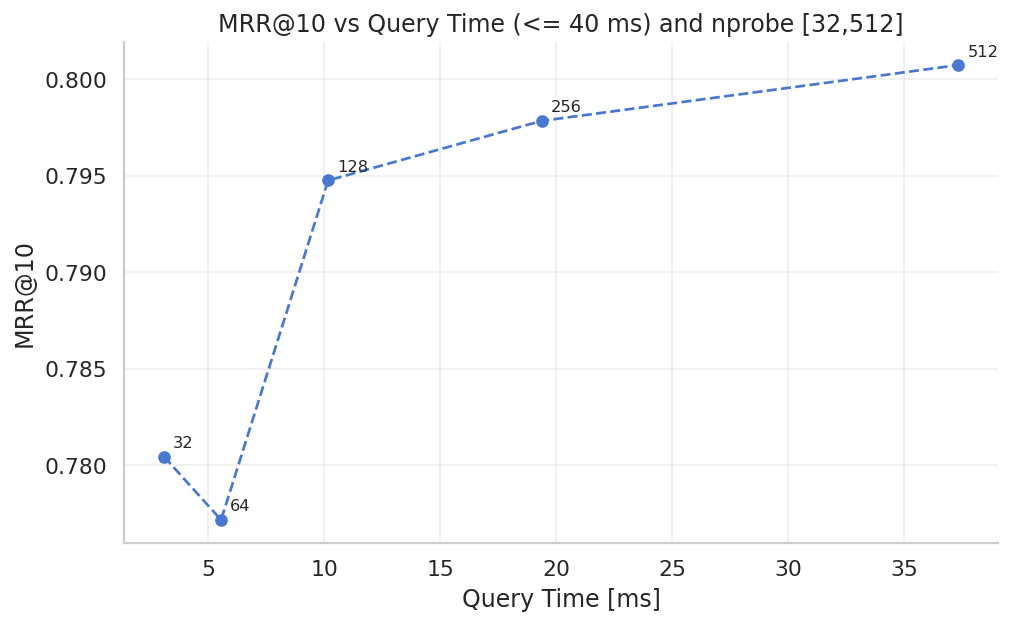

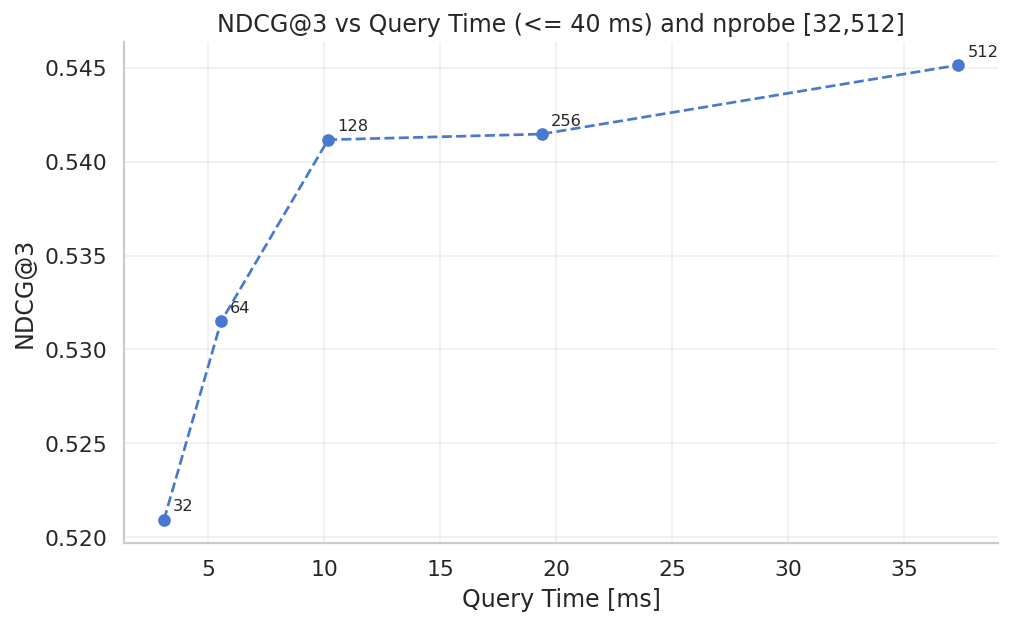

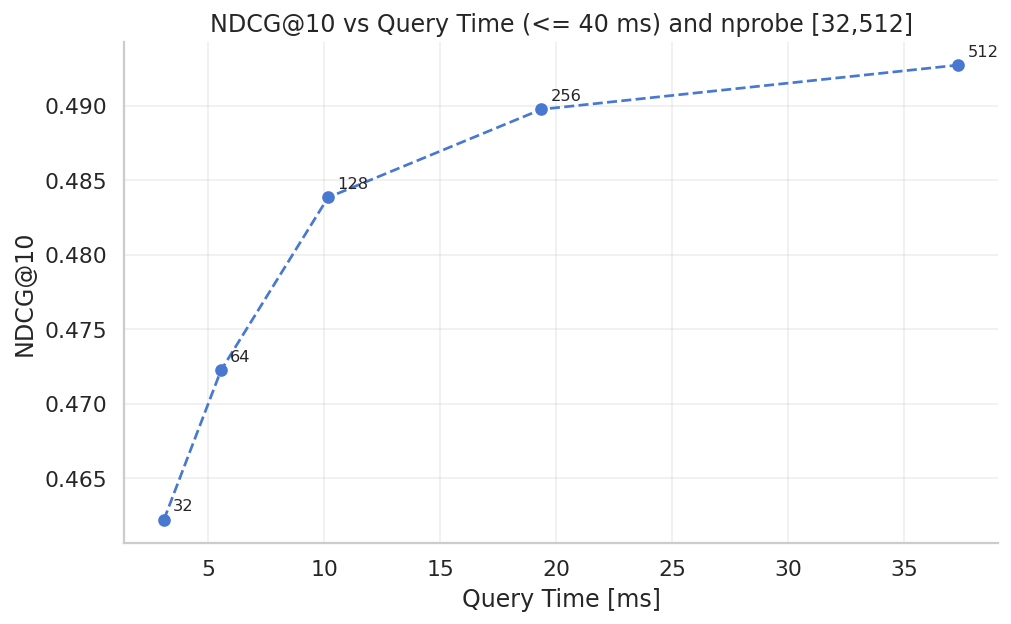

In [14]:
# Filter data up to 37 ms
df_filtered = df[
    (df["avg_query_time_ms"] <= 40) &
    (df["nprobe"] >= 32) &
    (df["nprobe"] <= 512)
].sort_values("avg_query_time_ms")

metrics = ["MRR@10", "NDCG@3", "NDCG@10"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    
    plt.plot(
        df_filtered["avg_query_time_ms"],
        df_filtered[metric],
        marker="o",
        linestyle="--"
    )
    
    # annotate nprobe values
    for _, row in df_filtered.iterrows():
        plt.annotate(
            str(int(row["nprobe"])),
            (row["avg_query_time_ms"], row[metric]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )
    
    plt.title(f"{metric} vs Query Time (<= 40 ms) and nprobe [32,512]")
    plt.xlabel("Query Time [ms]")
    plt.ylabel(metric)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 2 · Latency vs nprobe

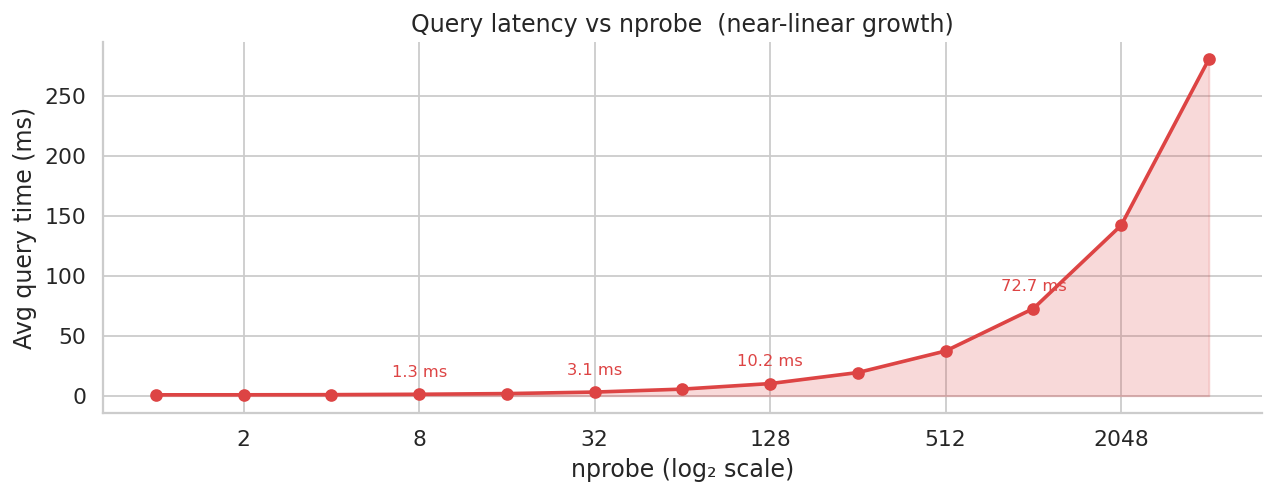

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.fill_between(df['nprobe'], df['avg_query_time_ms'], alpha=0.2, color=RED)
ax.plot(df['nprobe'], df['avg_query_time_ms'], color=RED, marker='o', linewidth=2, markersize=6)

# annotate key points
for row in df[df['nprobe'].isin([8, 32, 128, 1024])].itertuples():
    ax.annotate(f'{row.avg_query_time_ms:.1f} ms',
                xy=(row.nprobe, row.avg_query_time_ms),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=RED)

ax.set_xscale('log', base=2)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: int(x)))
ax.set_xlabel('nprobe (log₂ scale)')
ax.set_ylabel('Avg query time (ms)')
ax.set_title('Query latency vs nprobe  (near-linear growth)')
plt.tight_layout()
plt.savefig('latency_vs_nprobe.png', bbox_inches='tight')
plt.show()

## 3 · Quality / Latency trade-off (Pareto frontier)

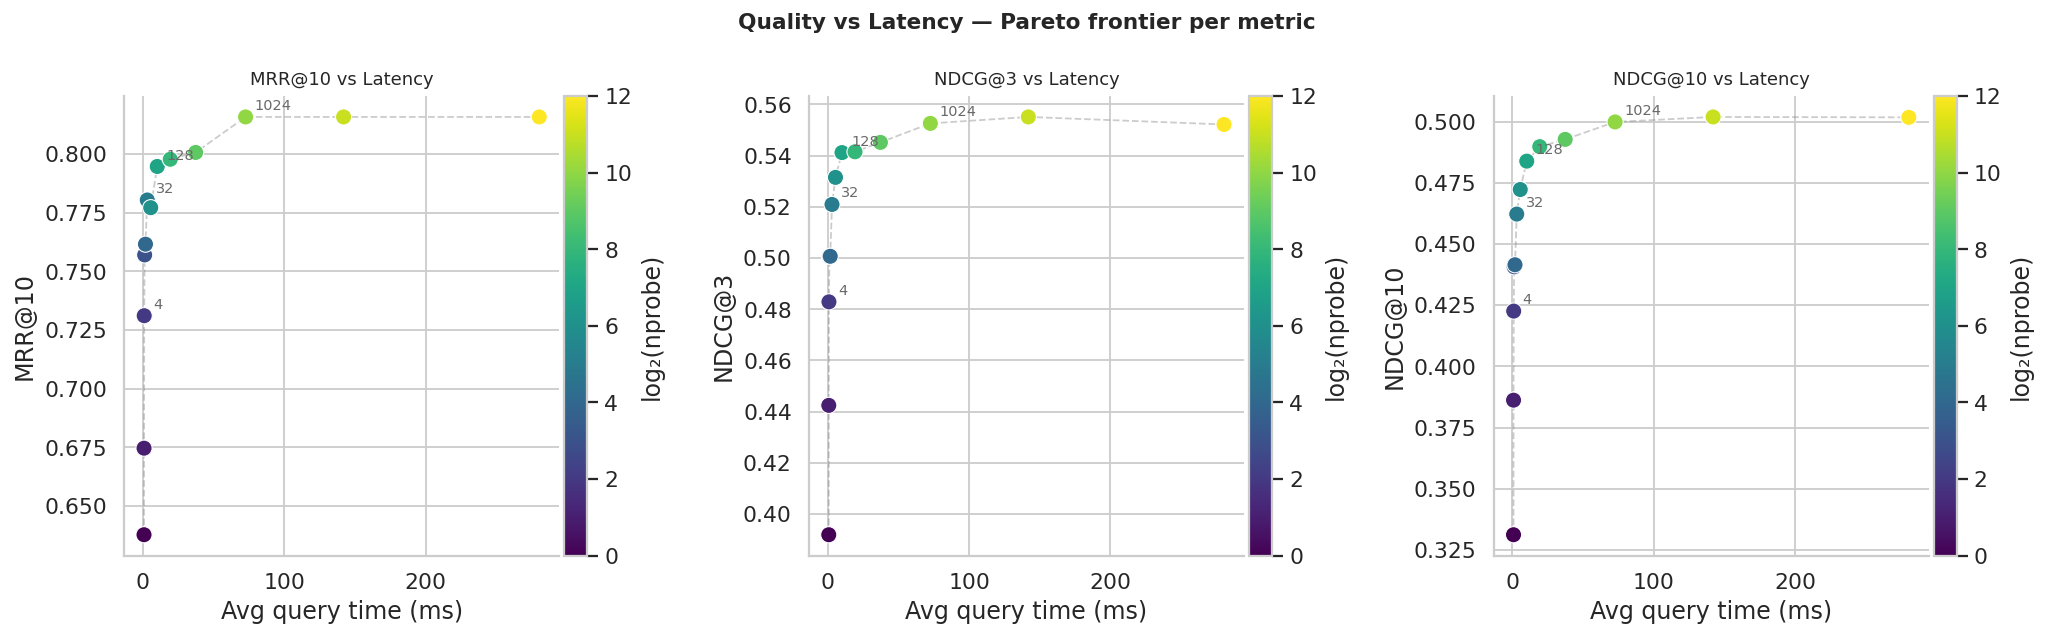

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Quality vs Latency — Pareto frontier per metric', fontsize=12, fontweight='bold')

HIGHLIGHT = [4, 32, 128, 1024]

METRICS = ['MRR@10', 'NDCG@3', 'NDCG@10']
for m in METRICS:
    df[f'{m}_gain']   = df[m].diff()
    df[f'{m}_pct']    = df[m].pct_change().mul(100)
    df[f'{m}_norm']   = (df[m] - df[m].min()) / (df[m].max() - df[m].min())
    df[f'{m}_eff']    = df[m] / df['avg_query_time_ms']
    df[f'{m}_pct_of_max'] = df[m] / df[m].max() * 100

for ax, metric in zip(axes, METRICS):
    color = COLORS[metric]
    sc = ax.scatter(df['avg_query_time_ms'], df[metric],
                    c=np.log2(df['nprobe']), cmap='viridis',
                    s=80, zorder=3, edgecolors='white', linewidth=0.6)
    ax.plot(df['avg_query_time_ms'], df[metric], '--', color='grey', alpha=0.4, linewidth=1)

    for _, row in df[df['nprobe'].isin(HIGHLIGHT)].iterrows():
        ax.annotate(f"{int(row['nprobe'])}",
                    xy=(row['avg_query_time_ms'], row[metric]),
                    xytext=(5, 4), textcoords='offset points',
                    fontsize=8, color='dimgrey')

    ax.set_xlabel('Avg query time (ms)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Latency', fontsize=10)
    plt.colorbar(sc, ax=ax, label='log₂(nprobe)', pad=0.01)

plt.tight_layout()
plt.savefig('pareto_per_metric.png', bbox_inches='tight')
plt.show()

**Interpretation:**
- The Pareto shape is consistent across all three metrics: steep improvements at low latency, then a long flat tail.
- The **knee of the curve** (best trade-off) is around **nprobe=32–128** for all metrics.
- **NDCG@10** shows the steepest rise initially — it benefits most from moving from nprobe=1 to 32.
- All curves flatten after ~10 ms of latency, confirming that spending more than 10 ms per query gives marginal returns.

## 6 · Quantitative evaluation

In [20]:
# Plateau detection: where MRR@10 stops improving by > 1 pp
plateau_row = df[df['mrr_gain'].abs() < 0.01].iloc[0] if not df[df['mrr_gain'].abs() < 0.01].empty else df.iloc[-1]
best_quality = df.loc[df['MRR@10'].idxmax()]
best_efficiency = df.loc[df['efficiency'].idxmax()]

mrr_range = df['MRR@10'].max() - df['MRR@10'].min()
lat_range = df['avg_query_time_ms'].max() - df['avg_query_time_ms'].min()

print('=' * 60)
print('nprobe SWEEP — EVALUATION SUMMARY')
print('=' * 60)

print(f"""
📊 Range of scores
  MRR@10  : {df['MRR@10'].min():.4f}  →  {df['MRR@10'].max():.4f}  (Δ {mrr_range:.4f})
  NDCG@3  : {df['NDCG@3'].min():.4f}  →  {df['NDCG@3'].max():.4f}
  NDCG@10 : {df['NDCG@10'].min():.4f}  →  {df['NDCG@10'].max():.4f}
  Latency : {df['avg_query_time_ms'].min():.2f} ms  →  {df['avg_query_time_ms'].max():.2f} ms  (×{lat_range/df['avg_query_time_ms'].min():.0f} slower at max)

🏆 Best quality
  nprobe={int(best_quality['nprobe'])}  →  MRR@10={best_quality['MRR@10']:.4f},  latency={best_quality['avg_query_time_ms']:.1f} ms

⚡ Best efficiency (MRR@10 / ms)
  nprobe={int(best_efficiency['nprobe'])}  →  MRR@10={best_efficiency['MRR@10']:.4f},  latency={best_efficiency['avg_query_time_ms']:.2f} ms

📈 Key observations
  • nprobe 1→4  : biggest quality jump  (+{df.loc[df['nprobe']==4,'MRR@10'].values[0] - df.loc[df['nprobe']==1,'MRR@10'].values[0]:.3f} MRR@10)
  • nprobe 32→128 : elbow — good balance zone
  • nprobe ≥1024 : quality plateau (MRR@10 flat at {df.loc[df['nprobe']>=1024,'MRR@10'].min():.4f})
  • Latency scales linearly with nprobe (doubling nprobe ≈ doubling latency)
""")



nprobe SWEEP — EVALUATION SUMMARY

📊 Range of scores
  MRR@10  : 0.6378  →  0.8159  (Δ 0.1781)
  NDCG@3  : 0.3920  →  0.5551
  NDCG@10 : 0.3313  →  0.5019
  Latency : 0.81 ms  →  280.34 ms  (×344 slower at max)

🏆 Best quality
  nprobe=1024  →  MRR@10=0.8159,  latency=72.7 ms

⚡ Best efficiency (MRR@10 / ms)
  nprobe=2  →  MRR@10=0.6747,  latency=0.83 ms

📈 Key observations
  • nprobe 1→4  : biggest quality jump  (+0.093 MRR@10)
  • nprobe 32→128 : elbow — good balance zone
  • nprobe ≥1024 : quality plateau (MRR@10 flat at 0.8159)
  • Latency scales linearly with nprobe (doubling nprobe ≈ doubling latency)

